# Inactive Moodle Users Analysis
Analysis of accounts in Moodle that have not been active in 2024, 2025 and 2026

In [41]:
# dependencies
import pandas as pd
import numpy as np
from datetime import datetime
from datetime import timedelta
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# import data
user_path = 'C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/MoodleUser/Jul2026/Users.xlsx'

users_pd = pd.read_excel(user_path)

users_pd.head()

In [25]:
# number of users who never logged in 
inactive = len(users_pd.loc[users_pd['Last access'] == 'Never'])

print(f"There {inactive} inactive users on Moodle")


There 29 inactive users on Moodle


In [26]:
# list of active learners
active = users_pd.loc[~(users_pd['Last access'] == 'Never')]

print(users_pd.shape)
print(active.shape)

(121963, 3)
(121934, 3)


In [ ]:
# list of active learners have access over one year
year_user = active.loc[(active['Last access'].str.contains('year'))]
year_user

In [28]:
# preprocessing Last access column
year_split = year_user['Last access'].str.split('year')

year_user['year'] = [x[0] for x in year_split]


C:\Users\ywa\AppData\Local\Temp\ipykernel_8616\3765517605.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  year_user['year'] = [x[0] for x in year_split]


In [ ]:
year_user['year'] = year_user['year'].str.strip().astype('int')

year_user.head()

In [ ]:
# regular expression
day_reg = r'(\d+)\s+day[s]?'

day_split = year_user['Last access'].str.extract(day_reg)[0].fillna(0).astype(int)

year_user['day'] = day_split

year_user.head()

In [ ]:
# using timedelta to get year
year_user['year_day'] = pd.Timestamp.now() - pd.to_timedelta((year_user['year'] * 365.25 + year_user['day']), unit = 'D') 

year_user.head()

In [ ]:
year_user['date'] = year_user['year_day'].dt.year
year_user.head()

In [44]:
# last access
user_2024 = len(year_user.loc[year_user['date'] < 2024])

# last access 2025
user_2025 = len(year_user.loc[year_user['date'] < 2025])

# last access 2026
user_2026 = len(year_user.loc[year_user['date'] < 2026])

print(f"{user_2024} users haven't been active since 2024, {user_2025} users haven't been active in 2025, {user_2026} users haven't been active in 2026")


2833 users haven't been active since 2024, 16821 users haven't been active in 2025, 36660 users haven't been active in 2026


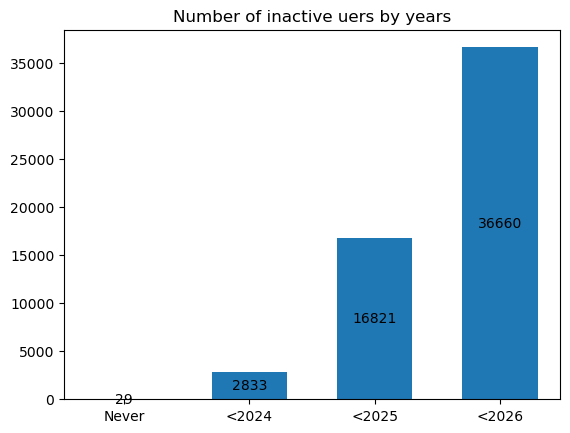

In [45]:
# plot the numbers of not active users
x = ['Never', '<2024', '<2025', '<2026']
y = [inactive, user_2024, user_2025, user_2026]

width = 0.6

fig, ax = plt.subplots()
plot = ax.bar(x, y, width)
ax.bar_label(plot, label_type = 'center')

ax.set_title('Number of inactive uers by years')
plt.show()

